In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [3]:
train = datasets.MNIST('../data', train=True, 
                       #download=True, 
                       transform=transforms.Compose([transforms.ToTensor()]))
test = datasets.MNIST('../data', train=False, 
                      transform=transforms.Compose([transforms.ToTensor()]))
print(train, test)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           ) Dataset MNIST
    Number of datapoints: 10000
    Root location: ../data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
           )


In [4]:
def plot(X):
    img = np.array(X.detach().to('cpu'), dtype='float').reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_11220\4150275479.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  img = np.array(X.detach().to('cpu'), dtype='float').reshape(28, 28)


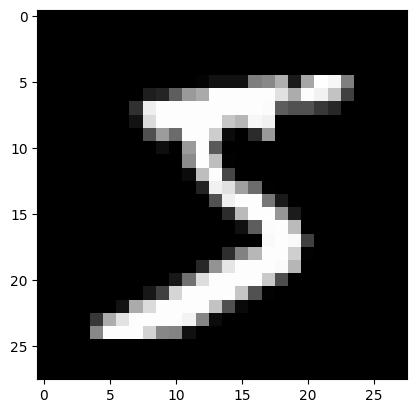

In [5]:
plot(train.data[0])

In [6]:
X = train.data.float() / 255
X = X.reshape(X.shape[0], -1)
y = train.targets
print(X.shape, y.shape)

torch.Size([60000, 784]) torch.Size([60000])


In [7]:
input_size = X.shape[-1]
output_size = int(max(y)) + 1
print(input_size, output_size)

784 10


In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)
X_test, y_test = test.data.float() / 255, test.targets
X_test = X_test.reshape(X_test.shape[0], -1)
print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

torch.Size([48000, 784]) torch.Size([12000, 784]) torch.Size([10000, 784]) torch.Size([48000]) torch.Size([12000]) torch.Size([10000])


In [9]:
lowest_loss = np.inf
best_model = None
early_stop = 100
lowest_epoch = np.inf

In [10]:
n_epochs = 5000
batch_size = 512
learning_rate = 1e-4
print_interval = 100

In [11]:
model = nn.Sequential(
    nn.Linear(input_size, 500),
    nn.LeakyReLU(),
    nn.Linear(500, 400),
    nn.LeakyReLU(),
    nn.Linear(400, 300),
    nn.LeakyReLU(),
    nn.Linear(300, 200),
    nn.LeakyReLU(),
    nn.Linear(200, 100),
    nn.LeakyReLU(),
    nn.Linear(100, 50),
    nn.LeakyReLU(),
    nn.Linear(50, output_size),
    nn.LogSoftmax(dim=-1)
)
model = model.to(device)
print(model)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
crit = nn.NLLLoss()

Sequential(
  (0): Linear(in_features=784, out_features=500, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=500, out_features=400, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=400, out_features=300, bias=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Linear(in_features=300, out_features=200, bias=True)
  (7): LeakyReLU(negative_slope=0.01)
  (8): Linear(in_features=200, out_features=100, bias=True)
  (9): LeakyReLU(negative_slope=0.01)
  (10): Linear(in_features=100, out_features=50, bias=True)
  (11): LeakyReLU(negative_slope=0.01)
  (12): Linear(in_features=50, out_features=10, bias=True)
  (13): LogSoftmax(dim=-1)
)


In [12]:
train_history, valid_history = [], []

for i in range(n_epochs):
    indices = torch.randperm(X_train.shape[0])
    X_ = torch.index_select(X_train, dim=0, index=indices).to(device)
    y_ = torch.index_select(y_train, dim=0, index=indices).to(device)

    X_ = X_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)

    train_loss = 0
    y_hat = []

    for X_i, y_i in zip(X_, y_):
        y_hat_i = model(X_i)
        loss = crit(y_hat_i, y_i.squeeze())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += float(loss.detach())
    
    train_loss = train_loss / len(X_)

    with torch.no_grad():
        X_ = X_val.to(device).split(batch_size, dim=0)
        y_ = y_val.to(device).split(batch_size, dim=0)

        valid_loss = 0

        for X_i, y_i in zip(X_, y_):
            y_hat_i = model(X_i)
            loss = crit(y_hat_i, y_i.squeeze())

            valid_loss += float(loss.detach())

            y_hat += [y_hat_i]
        
        valid_loss = valid_loss / len(X_)
    
    train_history += [train_loss]
    valid_history += [valid_loss]

    if (i + 1) % print_interval == 0:
        print(f'Epoch {i + 1}: train loss={train_loss:.4f}, valid loss={valid_loss:.4f}, lowest loss={lowest_loss:.4f}')
    
    if valid_loss < lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = i

        best_model = deepcopy(model.state_dict())
    else:
        if early_stop > 0 and lowest_epoch + early_stop < i + 1:
            print(f'There is no improvement during last {early_stop} epochs.')
            break

print(f'The best validation loss from epoch {lowest_epoch + 1}: {lowest_loss:.4f}')

model.load_state_dict(best_model)

Epoch 100: train loss=0.0001, valid loss=0.2407, lowest loss=0.1169
There is no improvement during last 100 epochs.
The best validation loss from epoch 33: 0.1169


<All keys matched successfully>

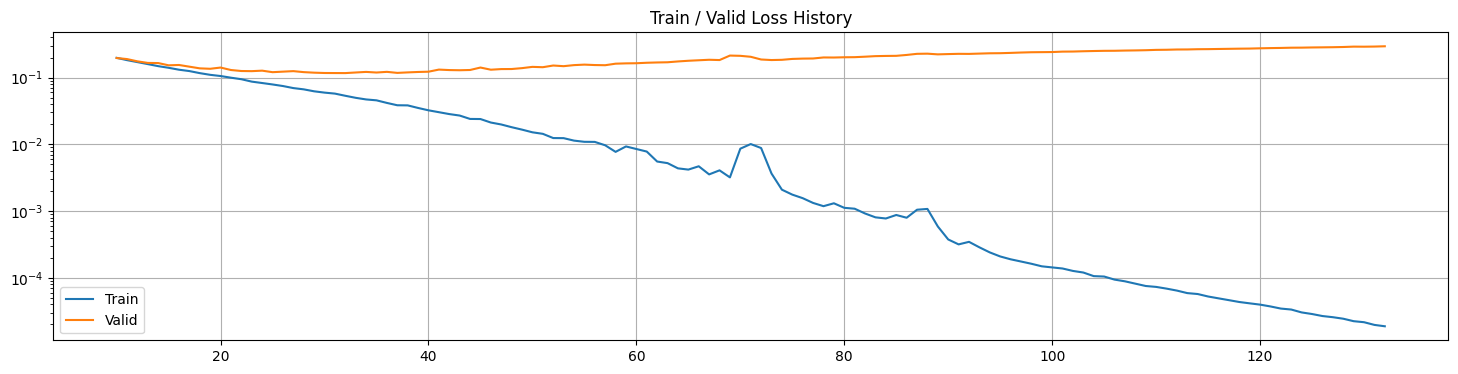

In [13]:
plot_from = 10

fig, ax = plt.subplots(1, 1, figsize=(18, 4))
plt.title('Train / Valid Loss History')
ax.plot(range(plot_from, len(train_history)), train_history[plot_from:],
         range(plot_from, len(valid_history)), valid_history[plot_from:])
plt.grid(True)
plt.yscale('log')
plt.legend(['Train', 'Valid'])
plt.show()

In [14]:
test_loss = 0
y_hat = []

with torch.no_grad():
    X_ = X_test.to(device).split(batch_size, dim=0)
    y_ = y_test.to(device).split(batch_size, dim=0)

    for X_i, y_i in zip(X_, y_):
        y_hat_i = model(X_i)
        loss = crit(y_hat_i, y_i.squeeze())

        test_loss += float(loss.detach())

        y_hat += [y_hat_i]
    
    test_loss = test_loss / len(X_)

y_hat = torch.concat(y_hat, dim=0)

In [15]:
sorted_history = sorted(zip(train_history, valid_history), key=lambda x: x[1])

print(f'Train loss: {sorted_history[0][0]:.4f}')
print(f'Valid loss: {sorted_history[0][1]:.4f}')
print(f'Test loss: {test_loss:.4f}')

Train loss: 0.0534
Valid loss: 0.1169
Test loss: 0.1173


In [16]:
correct_cnt = (y_test.squeeze() == torch.argmax(y_hat.to('cpu'), dim=-1)).sum()
total_cnt = y_test.shape[0]

print(f'Test Accuracy: {correct_cnt / total_cnt:.2f}')

Test Accuracy: 0.97


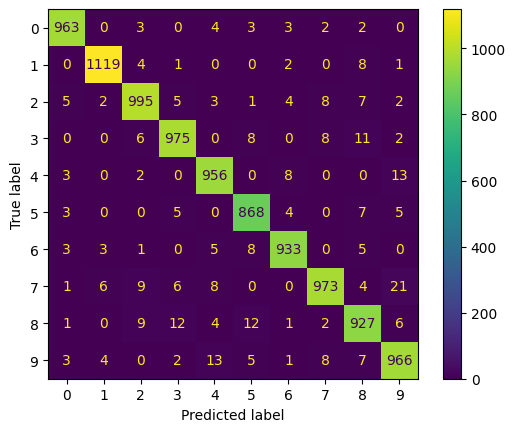

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test.squeeze(), torch.argmax(y_hat.to('cpu'), dim=-1))

In [18]:
del model
torch.cuda.empty_cache()